In [7]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
import pandas as pd
from sklearn.cluster import DBSCAN

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

# from src import Multicolour_Simulation_Functions

# MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

mosaic_unit = np.array([["R", "G"], ["G", "B"]])
M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions(mosaic_unit=mosaic_unit)

import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import localise
from src import postprocess
from src import render
import DriftCorrectionFunctions as DCF


import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../../Camera_Calibrations/ZWO_Camera"
# data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

/tmp/ipykernel_4129350/1263847923.py:27: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [10]:
image_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260402_HJs/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_4'
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

Summing 50 frames (frames 0 to 49) for spot detection


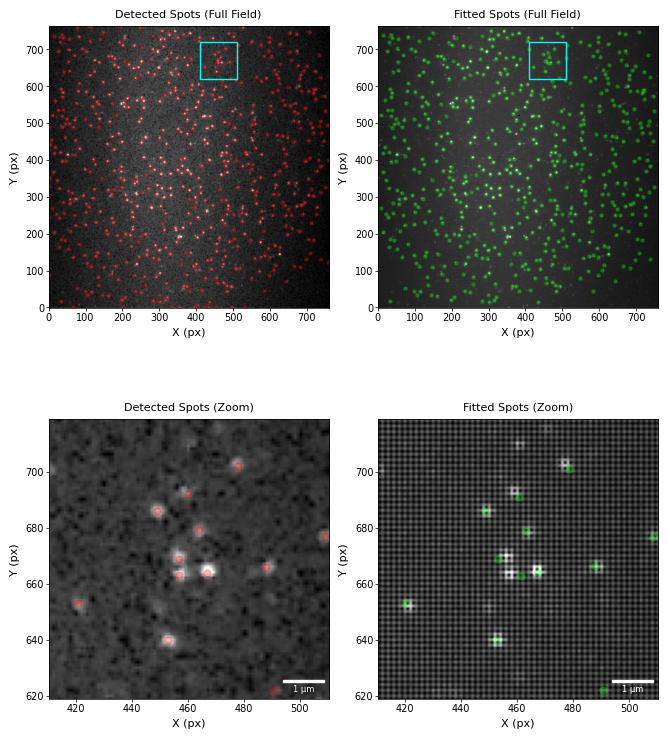

In [11]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.1
peak_wavelength = 0.6
frame_index = 0
n_frames_sum=50
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength,
                                             n_frames_sum=n_frames_sum, ROI_size=16)
plt.show()

In [7]:
SupRes_F.fit_FRET_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    sigma=sigma,
    fraction_true=fraction_true,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
    n_frames_sum=n_frames_sum,
)


Processing file 1/16: 5pM_HJ_40p561_568lp_DC2_emptyfilterweheel_1_MMStack_1-Pos000_000.ome.tif
Phase 1: Detecting spots on summed frames (n=50)
  Detected 180 spots on summed image
Phase 2: Extracting time traces for detected spots
Phase 3: Running change point detection


Finding change points: 100%|███████████████| 180/180 [00:12<00:00, 14.28batch/s]


Found 72 puncta with change points out of 180 total
Phase 4: Fitting 72 spots with change points
  Total ROIs to fit: 8888
  Processing frames 0 to 401


Loading frames: 100%|█████████████████████████████| 1/1 [00:08<00:00,  8.14s/it]

  Accumulated 8888 ROIs for fitting
  Running parallel fitting...


...

Finding change points: 100%|███████████████| 183/183 [00:12<00:00, 14.87batch/s]


Found 86 puncta with change points out of 183 total
Phase 4: Fitting 86 spots with change points
  Total ROIs to fit: 8351
  Processing frames 0 to 382


Loading frames: 100%|█████████████████████████████| 1/1 [00:07<00:00,  7.72s/it]

  Accumulated 8351 ROIs for fitting
  Running parallel fitting...


  Saved 7004 fits to /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/20mMMgCl2/5pM_HJ_40p561_568lp_DC2_emptyfilterweheel_1/5pM_HJ_40p561_568lp_DC2_emptyfilterweheel_1_MMStack_1-Pos003_003.h5

FRET analysis complete for all 16 files.


In [5]:
image_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_40p561_568lp_DC2_emptyfilterweheel_50msExposure_1'
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

Summing 50 frames (frames 0 to 49) for spot detection


/home/jsb92/Documents/pyBayerSMLM/FRET_notebooks/../src/SR_Functions.py:995: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


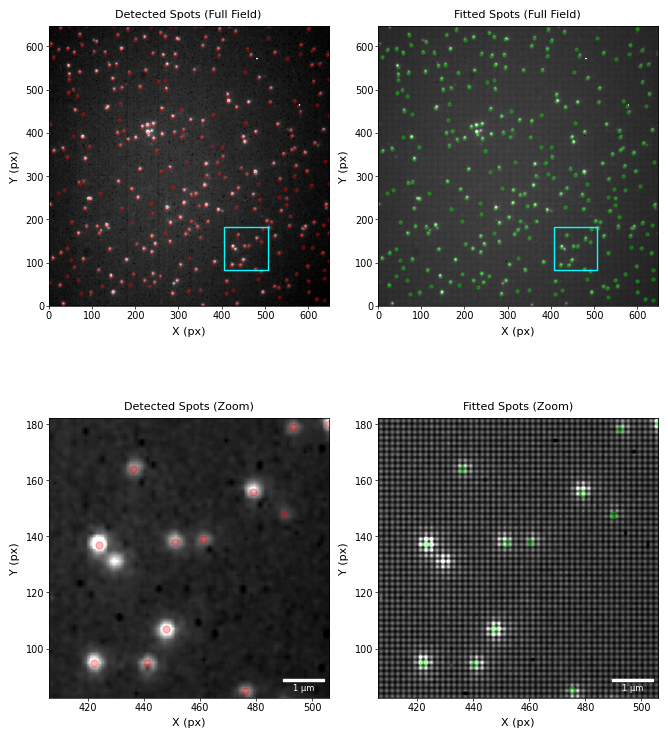

In [6]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.1
peak_wavelength = 0.6
frame_index = 0
n_frames_sum = 50
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength,
                                             n_frames_sum=n_frames_sum)
plt.show()

In [7]:
SupRes_F.fit_FRET_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    sigma=sigma,
    fraction_true=fraction_true,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
    n_frames_sum=n_frames_sum,
)


Processing file 1/25: 20pM_HJ_40p561_568lp_DC2_emptyfilterweheel_50msExposure_1_MMStack_1-Pos000_000.ome.tif
Phase 1: Detecting spots on summed frames (n=50)
  Detected 306 spots on summed image
Phase 2: Extracting time traces for detected spots
Phase 3: Running change point detection


Finding change points: 100%|███████████████| 306/306 [01:22<00:00,  3.73batch/s]


Found 223 puncta with change points out of 306 total
Phase 4: Fitting 223 spots with change points
  Total ROIs to fit: 48121
  Processing frames 0 to 831


Loading frames: 100%|█████████████████████████████| 2/2 [00:16<00:00,  8.22s/it]

  Accumulated 48121 ROIs for fitting
  Running parallel fitting...


...

Finding change points: 100%|███████████████| 283/283 [01:11<00:00,  3.98batch/s]


Found 213 puncta with change points out of 283 total
Phase 4: Fitting 213 spots with change points
  Total ROIs to fit: 55316
  Processing frames 0 to 821


Loading frames: 100%|█████████████████████████████| 2/2 [00:16<00:00,  8.20s/it]

  Accumulated 55316 ROIs for fitting
  Running parallel fitting...


  Saved 47274 fits to /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_40p561_568lp_DC2_emptyfilterweheel_50msExposure_1/20pM_HJ_40p561_568lp_DC2_emptyfilterweheel_50msExposure_1_MMStack_1-Pos004_004.h5

FRET analysis complete for all 25 files.


In [8]:
image_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_60p561_568lp_DC2_emptyfilterweheel_20msExposure_1'
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

Summing 50 frames (frames 0 to 49) for spot detection


/home/jsb92/Documents/pyBayerSMLM/FRET_notebooks/../src/SR_Functions.py:995: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


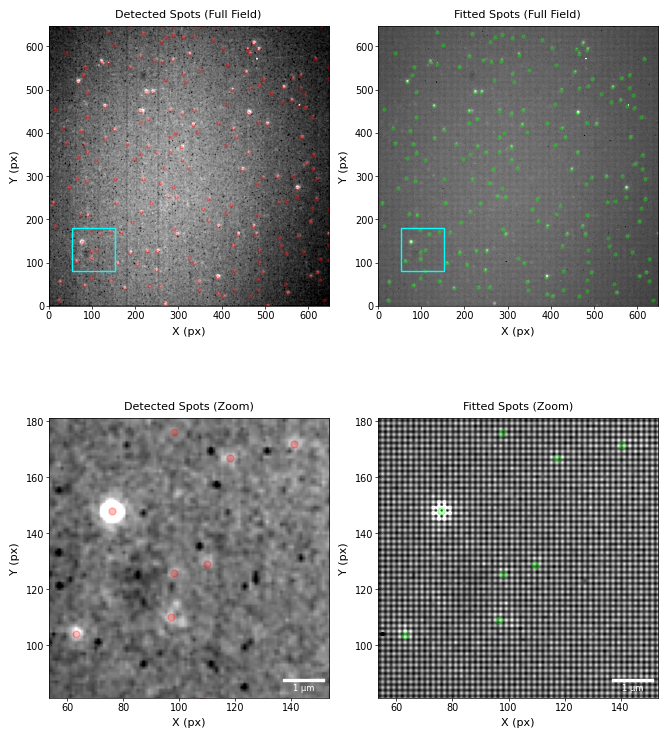

In [9]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.1
peak_wavelength = 0.6
frame_index = 0
n_frames_sum = 50
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength,
                                             n_frames_sum=n_frames_sum)
plt.show()

In [10]:
SupRes_F.fit_FRET_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    sigma=sigma,
    fraction_true=fraction_true,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
    n_frames_sum=n_frames_sum,
)


Processing file 1/25: 20pM_HJ_60p561_568lp_DC2_emptyfilterweheel_20msExposure_1_MMStack_3-Pos000_000.ome.tif
Phase 1: Detecting spots on summed frames (n=50)
  Detected 209 spots on summed image
Phase 2: Extracting time traces for detected spots
Phase 3: Running change point detection


Finding change points: 100%|███████████████| 209/209 [01:04<00:00,  3.24batch/s]


Found 42 puncta with change points out of 209 total
Phase 4: Fitting 42 spots with change points
  Total ROIs to fit: 8066
  Processing frames 0 to 784


Loading frames: 100%|█████████████████████████████| 2/2 [00:16<00:00,  8.35s/it]

  Accumulated 8066 ROIs for fitting
  Running parallel fitting...


...

Finding change points: 100%|███████████████| 200/200 [00:56<00:00,  3.54batch/s]


Found 39 puncta with change points out of 200 total
Phase 4: Fitting 39 spots with change points
  Total ROIs to fit: 9796
  Processing frames 0 to 838


Loading frames: 100%|█████████████████████████████| 2/2 [00:17<00:00,  8.60s/it]

  Accumulated 9796 ROIs for fitting
  Running parallel fitting...


  Saved 8707 fits to /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_60p561_568lp_DC2_emptyfilterweheel_20msExposure_1/20pM_HJ_60p561_568lp_DC2_emptyfilterweheel_20msExposure_1_MMStack_3-Pos004_004.h5

FRET analysis complete for all 25 files.
